<a href="https://colab.research.google.com/github/hussainiram0601-lang/AI-Based-Chronic-Kidney-Disease-CKD-/blob/main/Machine_Learning_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Chronic Kidney Disease (CKD) Risk Prediction Machine Learning Pipelinne

# Module 1: Data Understanding & EDA

### Importing Libraries

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

### Load dataset

In [172]:
df = pd.read_csv("kidney_disease.csv")

### Dataset summary

In [173]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [174]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [176]:
df.shape

(400, 26)

In [177]:
df.isnull().sum()

,0
id,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4


In [178]:
df["classification"].value_counts()

,count
classification,
ckd,248
notckd,150
ckd\t,2


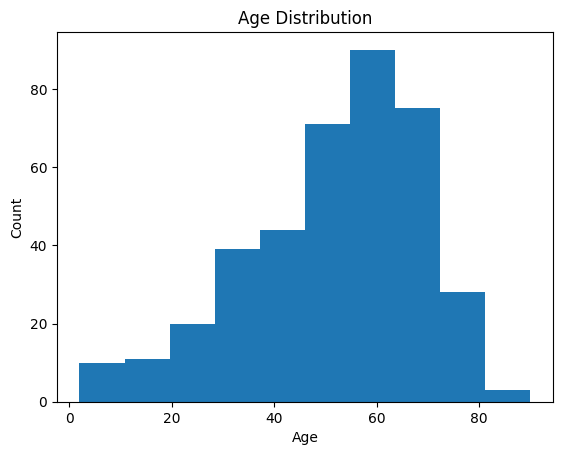

In [179]:
plt.hist(df["age"])
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

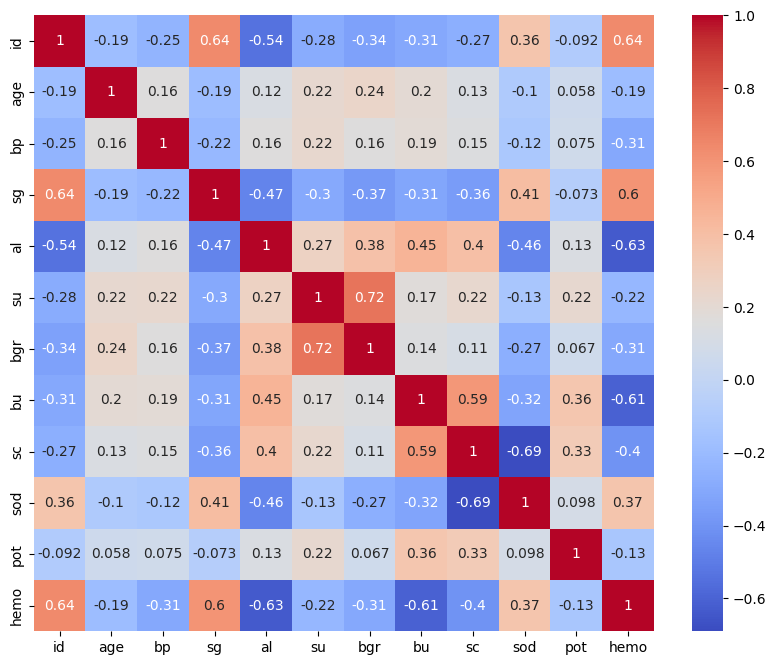

In [180]:
import seaborn as sns
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


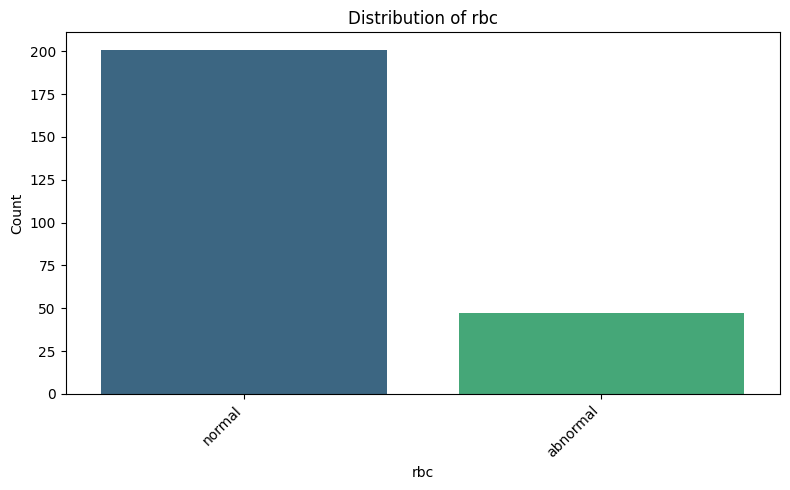

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


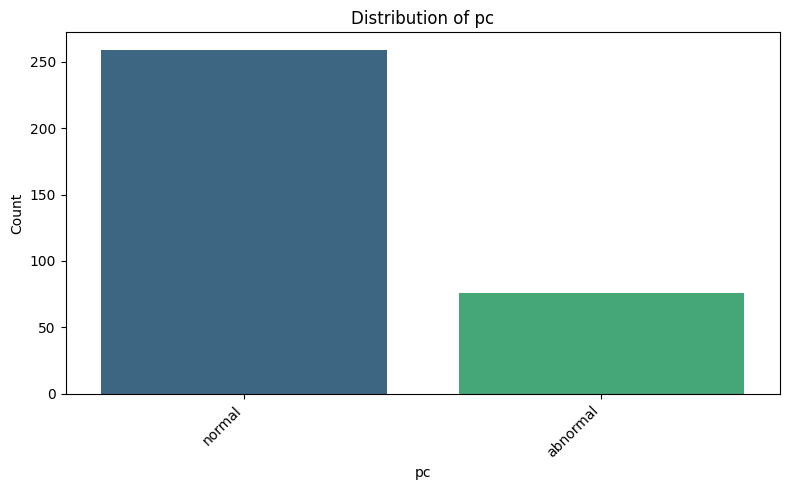

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


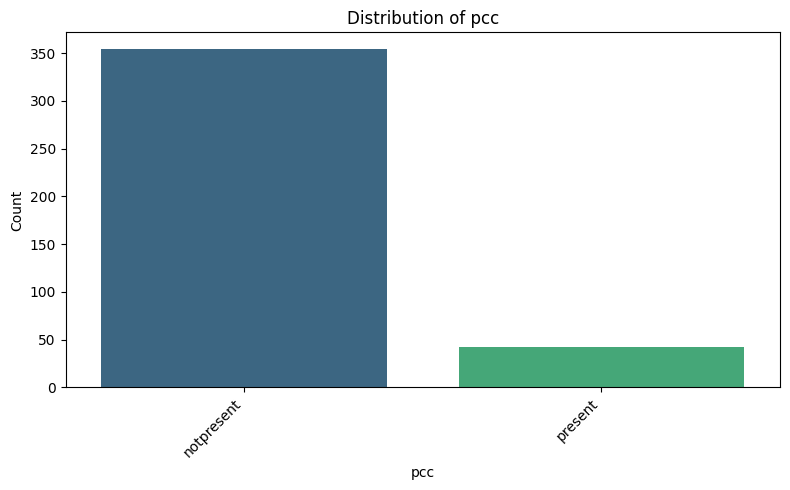

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


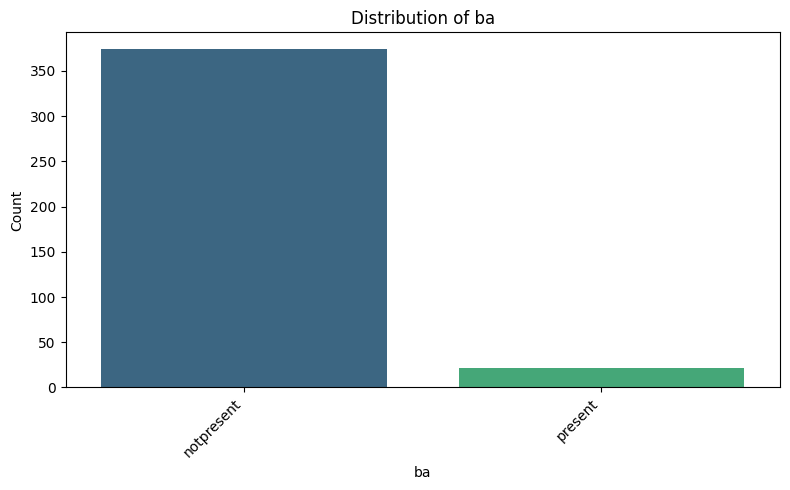

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_4837/4240319544.py:18: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


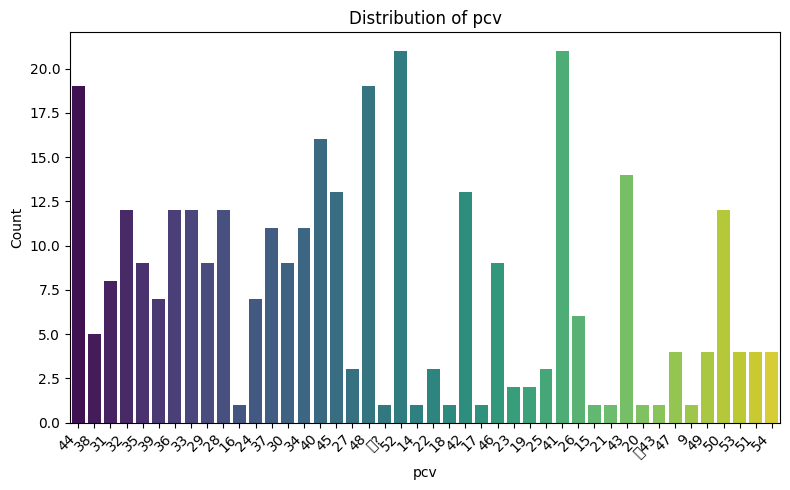

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_4837/4240319544.py:18: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


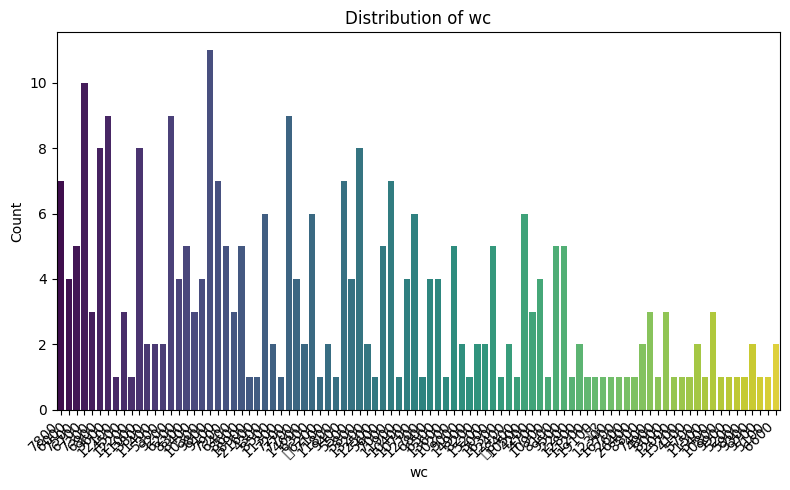

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_4837/4240319544.py:18: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


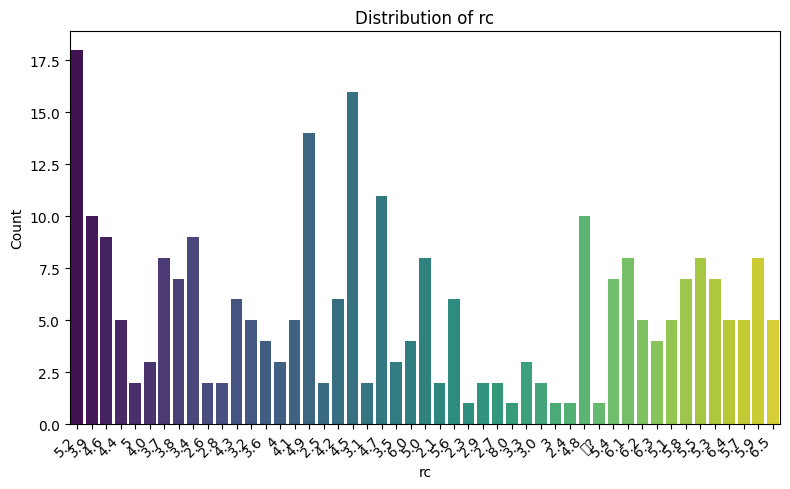

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


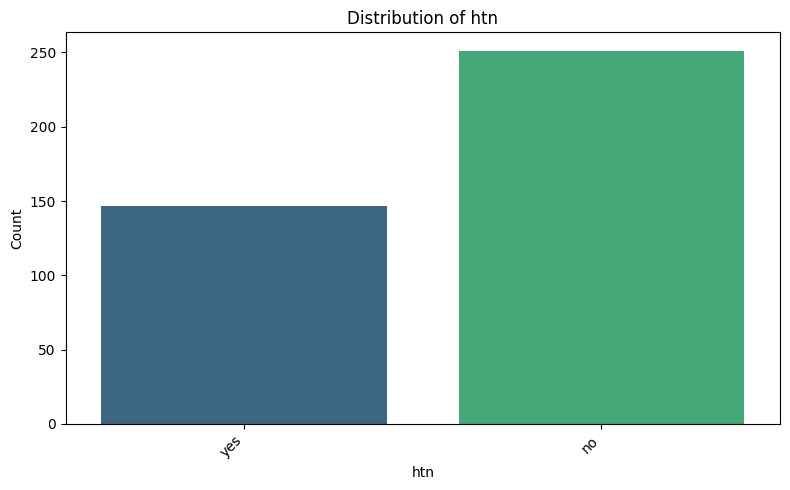

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_4837/4240319544.py:18: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


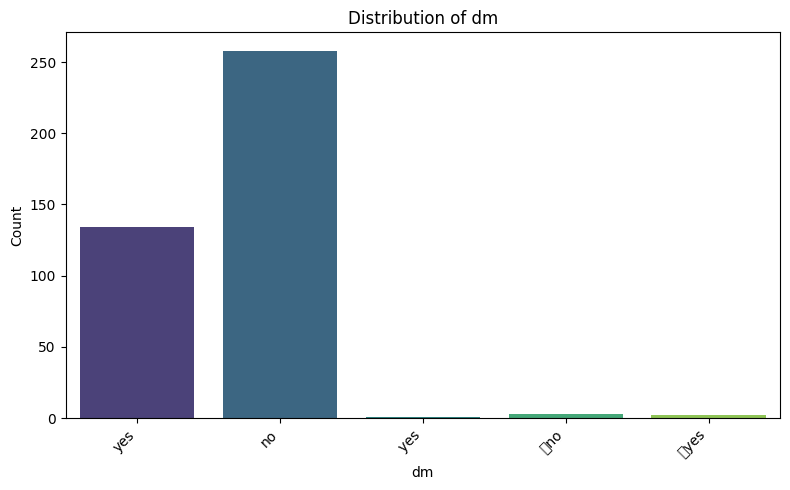

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_4837/4240319544.py:18: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


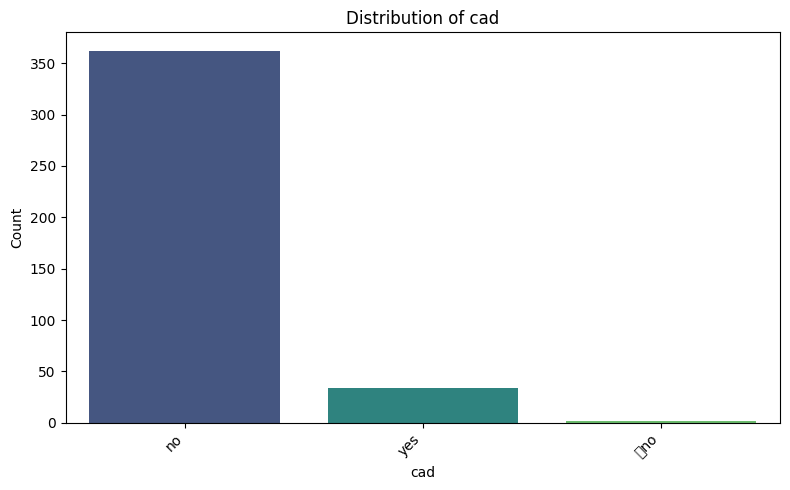

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


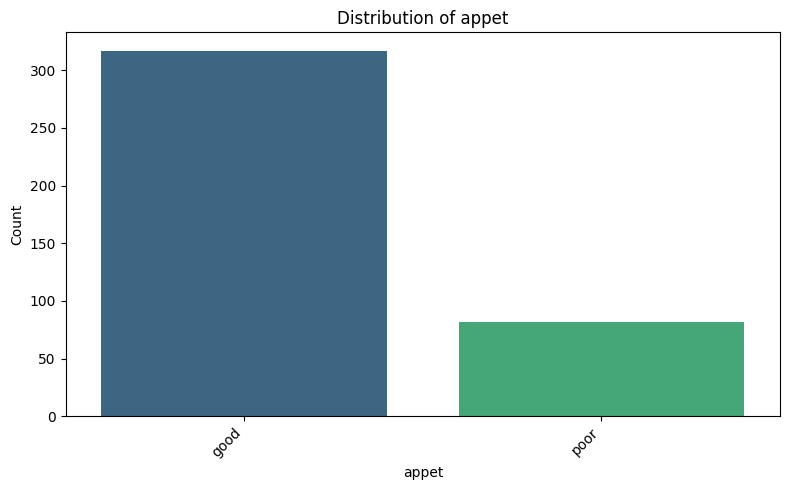

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


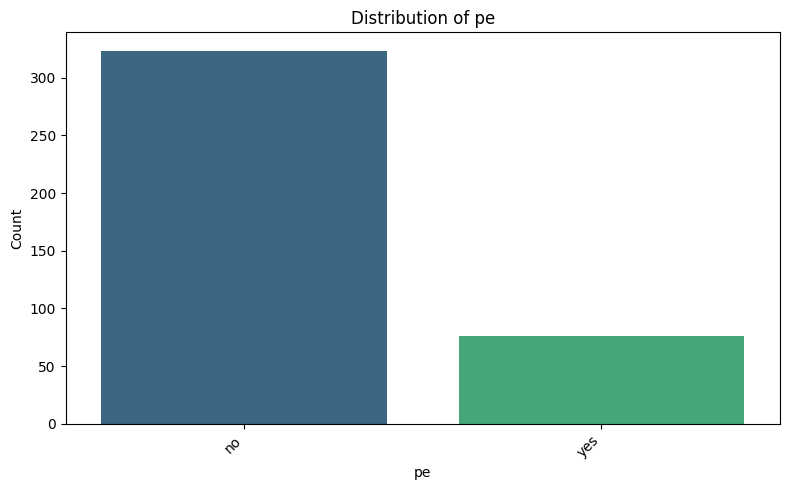

/tmp/ipykernel_4837/4240319544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


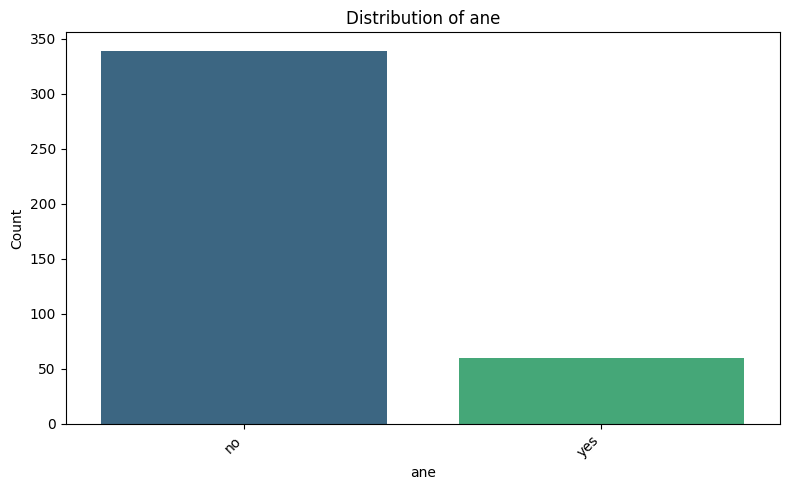

In [181]:
import seaborn as sns

# Get categorical columns (object type)
categorical_cols = df.select_dtypes(include=['object']).columns

# Remove 'classification' column from categorical_cols if present
if 'classification' in categorical_cols:
    categorical_cols = categorical_cols.drop('classification')

# Create count plots for each categorical feature
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

These plots show the distribution of each categorical feature. We can observe the value counts and potential imbalances or missing values in these columns.

# Data Cleaning and Preprocessing

In [182]:
#Drop Unnecessary Column
df.drop("id", axis=1, inplace=True)

df_clean = df.copy()

# ---------------------------------------------------------
# DUPLICATE ROW CHECK
# ---------------------------------------------------------

duplicate_count = df_clean.duplicated().sum()

print("Duplicate Row Check")
print("-------------------")
print("Number of duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("Result: No duplicate rows found.")
else:
    print(f"Result: {duplicate_count} duplicate rows found.")

    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

    print("Duplicates removed.")
    print("New shape:", df_clean.shape)

# Use cleaned dataframe for all remaining preprocessing
df = df_clean.copy()

print("\nMissing Values:")
print(df.isnull().sum())

Duplicate Row Check
-------------------
Number of duplicate rows: 0
Result: No duplicate rows found.

Missing Values:
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [183]:
df_clean.isnull().sum()

,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4
bgr,44


In [184]:
df["pcv"] = pd.to_numeric(df["pcv"], errors="coerce")
df["wc"] = pd.to_numeric(df["wc"], errors="coerce")
df["rc"] = pd.to_numeric(df["rc"], errors="coerce")

In [185]:
cat_cols = [
    "rbc",
    "pc",
    "pcc",
    "ba",
    "htn",
    "dm",
    "cad",
    "appet",
    "pe",
    "ane"
]



In [186]:
df["dm"] = df["dm"].replace({
    "\tyes": "yes",
    "\tno": "no",
    " yes": "yes",
    " no": "no"
})

In [187]:
for col in cat_cols:
    df[col] = (
        df[col]
        .astype(object)
        .apply(lambda x: x.strip().lower() if isinstance(x, str) else x)
    )

df["classification"] = (
    df["classification"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [188]:
for col in cat_cols + ["classification"]:
    print(col, df[col].unique())

rbc [nan 'normal' 'abnormal']
pc ['normal' 'abnormal' nan]
pcc ['notpresent' 'present' nan]
ba ['notpresent' 'present' nan]
htn ['yes' 'no' nan]
dm ['yes' 'no' nan]
cad ['no' 'yes' nan]
appet ['good' 'poor' nan]
pe ['no' 'yes' nan]
ane ['no' 'yes' nan]
classification ['ckd' 'notckd']


In [189]:
df["classification"] = df["classification"].replace({
    "ckd": 1,
    "notckd": 0
})

/tmp/ipykernel_4837/1877764795.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["classification"] = df["classification"].replace({


In [190]:
X = df.drop("classification", axis=1)
y = df["classification"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [191]:
num_cols = [
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
    "hemo",
    "pcv",
    "wc",
    "rc"
]

In [192]:
'''from sklearn.impute import KNNImputer

imputer = KNNImputer(
    n_neighbors=5,
    weights="distance"
)

df[num_cols] = imputer.fit_transform(df[num_cols])'''

'from sklearn.impute import KNNImputer\n\nimputer = KNNImputer(\n    n_neighbors=5,\n    weights="distance"\n)\n\ndf[num_cols] = imputer.fit_transform(df[num_cols])'

In [193]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,1


In [194]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("imputer", KNNImputer(
        n_neighbors=5,
        weights="distance"
    )),
    ("scaler", StandardScaler())
])

In [195]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ("encoder", OneHotEncoder(drop="first",handle_unknown="ignore"))
])

In [196]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [197]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [198]:
print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_preprocessed.shape)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_preprocessed.shape)

Original X_train shape: (320, 24)
Processed X_train shape: (320, 24)
Original X_test shape: (80, 24)
Processed X_test shape: (80, 24)


In [199]:
print("Missing values in X_train:", np.isnan(X_train_preprocessed).sum())
print("Missing values in X_test:", np.isnan(X_test_preprocessed).sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [200]:
print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_preprocessed.shape)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_preprocessed.shape)

print("Processed data type:", type(X_train_preprocessed))

Original X_train shape: (320, 24)
Processed X_train shape: (320, 24)
Original X_test shape: (80, 24)
Processed X_test shape: (80, 24)
Processed data type: <class 'numpy.ndarray'>


In [201]:
features_names = preprocessor.get_feature_names_out()

print('numbers of features:', len(features_names))
print("\nFeatures names are:")
for i , features in enumerate(features_names):
  print(i, features)

numbers of features: 24

Features names are:
0 num__age
1 num__bp
2 num__sg
3 num__al
4 num__su
5 num__bgr
6 num__bu
7 num__sc
8 num__sod
9 num__pot
10 num__hemo
11 num__pcv
12 num__wc
13 num__rc
14 cat__rbc_normal
15 cat__pc_normal
16 cat__pcc_present
17 cat__ba_present
18 cat__htn_yes
19 cat__dm_yes
20 cat__cad_yes
21 cat__appet_poor
22 cat__pe_yes
23 cat__ane_yes


In [202]:
print("\nMean of numerical features:")
print(X_train_preprocessed[:, :14].mean(axis=0))
print("\nStandard deviation of numerical features:")
print(X_train_preprocessed[:, :14].std(axis=0))


Mean of numerical features:
[-2.07472928e-16 -1.80584714e-16  3.15990289e-14  2.84494650e-17
  1.73819292e-16 -1.83880688e-17  1.42420797e-16 -2.23779328e-17
 -6.70123679e-16  5.97785710e-16  2.51187959e-16 -1.06165077e-16
  1.12410081e-16 -9.43689571e-17]

Standard deviation of numerical features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [203]:
print("Train shape:", X_train_preprocessed.shape)
print("Test shape:", X_test_preprocessed.shape)

print("Missing train:",
      np.isnan(X_train_preprocessed).sum())

print("Missing test:",
      np.isnan(X_test_preprocessed).sum())

print(preprocessor.get_feature_names_out())

Train shape: (320, 24)
Test shape: (80, 24)
Missing train: 0
Missing test: 0
['num__age' 'num__bp' 'num__sg' 'num__al' 'num__su' 'num__bgr' 'num__bu'
 'num__sc' 'num__sod' 'num__pot' 'num__hemo' 'num__pcv' 'num__wc'
 'num__rc' 'cat__rbc_normal' 'cat__pc_normal' 'cat__pcc_present'
 'cat__ba_present' 'cat__htn_yes' 'cat__dm_yes' 'cat__cad_yes'
 'cat__appet_poor' 'cat__pe_yes' 'cat__ane_yes']


In [204]:
from sklearn.linear_model import LogisticRegression

lg_model = LogisticRegression(random_state=42)
lg_model.fit(X_train_preprocessed, y_train)

y_pred = lg_model.predict(X_test_preprocessed)

In [205]:


print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print( "f1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9875
Precision: 1.0
Recall: 0.98
f1 Score: 0.98989898989899


In [206]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [207]:
cm =confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[30  0]
 [ 1 49]]


In [208]:
y_prob = lg_model.predict_proba(X_test_preprocessed)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9986666666666667


In [209]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state = 42)
dt_model.fit(X_train_preprocessed, y_train)

y_pred_dt = dt_model.predict(X_test_preprocessed)

In [210]:
y_prob_dt = dt_model.predict_proba(X_test_preprocessed)[:,1]
print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

Decision Tree
Accuracy : 0.9625
Precision: 0.9795918367346939
Recall   : 0.96
F1 Score : 0.9696969696969697
ROC-AUC  : 0.9633333333333334


In [211]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_preprocessed, y_train)

y_pred_rf = rf_model.predict(X_test_preprocessed)

In [212]:
y_prob_rf = rf_model.predict_proba(X_test_preprocessed)[:,1]
print("Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Random Forest
Accuracy : 0.975
Precision: 0.98
Recall   : 0.98
F1 Score : 0.98
ROC-AUC  : 0.9993333333333333


In [213]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_preprocessed,
    y_train
)

y_pred_svm = svm_model.predict(X_test_preprocessed)

y_prob_svm = svm_model.predict_proba(
    X_test_preprocessed
)[:, 1]
print("SVM")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_svm))

SVM
Accuracy : 0.9875
Precision: 1.0
Recall   : 0.98
F1 Score : 0.98989898989899
ROC-AUC  : 0.9986666666666667


In [214]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_preprocessed, y_train)

y_pred_knn = knn_model.predict(X_test_preprocessed)

y_prob_knn = knn_model.predict_proba(X_test_preprocessed)[:,1]
print("KNN")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_knn))

KNN
Accuracy : 0.95
Precision: 1.0
Recall   : 0.92
F1 Score : 0.9583333333333334
ROC-AUC  : 0.99


In [215]:
# tuning
from sklearn.model_selection import GridSearchCV

lg_param_grid ={
    "C":[0.01, 0.1, 1, 10, 100],
    "solver": [ "liblinear", "lbfgs"]
}

lg_grid =GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    lg_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

lg_grid.fit(X_train_preprocessed, y_train)

print("Best Parameters:", lg_grid.best_params_)
print("Best CV ROC-AUC:", lg_grid.best_score_)

Best Parameters: {'C': 10, 'solver': 'liblinear'}
Best CV ROC-AUC: 0.9995833333333334


In [216]:
# Get the best tuned Logistic Regression model
best_logistic = lg_grid.best_estimator_

# Class predictions: 0 or 1
y_pred_lr_tuned = best_logistic.predict(X_test_preprocessed)

# Probabilities: values between 0 and 1
y_prob_lr_tuned = best_logistic.predict_proba(
    X_test_preprocessed
)[:, 1]

print("Unique predictions:", np.unique(y_pred_lr_tuned))
print("First 10 predictions:", y_pred_lr_tuned[:10])
print("First 10 probabilities:", y_prob_lr_tuned[:10])

Unique predictions: [0 1]
First 10 predictions: [0 1 1 0 1 1 0 1 1 1]
First 10 probabilities: [3.85556394e-04 1.00000000e+00 9.99074854e-01 3.63551197e-04
 9.99999365e-01 9.99952580e-01 8.50464961e-06 1.00000000e+00
 9.95984597e-01 9.98385458e-01]


In [217]:
print("Tuned Logistic Regression")

print("Accuracy :", accuracy_score(y_test, y_pred_lr_tuned))
print("Precision:", precision_score(y_test, y_pred_lr_tuned))
print("Recall   :", recall_score(y_test, y_pred_lr_tuned))
print("F1 Score :", f1_score(y_test, y_pred_lr_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr_tuned))

Tuned Logistic Regression
Accuracy : 0.9875
Precision: 1.0
Recall   : 0.98
F1 Score : 0.98989898989899
ROC-AUC  : 0.9986666666666667


In [218]:
svm_param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "kernel": ["rbf", "linear"]
}

svm_grid = GridSearchCV(
    SVC(
        probability=True,
        random_state=42
    ),
    svm_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

svm_grid.fit(X_train_preprocessed, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best CV ROC-AUC:", svm_grid.best_score_)

Best Parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV ROC-AUC: 0.9989583333333332


In [219]:
best_svm = svm_grid.best_estimator_

y_pred_svm_tuned = best_svm.predict(X_test_preprocessed)

y_prob_svm_tuned = best_svm.predict_proba(
    X_test_preprocessed
)[:, 1]

print("Tuned SVM")

print("Accuracy :", accuracy_score(y_test, y_pred_svm_tuned))
print("Precision:", precision_score(y_test, y_pred_svm_tuned))
print("Recall   :", recall_score(y_test, y_pred_svm_tuned))
print("F1 Score :", f1_score(y_test, y_pred_svm_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_svm_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm_tuned))

Tuned SVM
Accuracy : 0.9875
Precision: 1.0
Recall   : 0.98
F1 Score : 0.98989898989899
ROC-AUC  : 0.998

Confusion Matrix:
[[30  0]
 [ 1 49]]


In [220]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
from pprint import pprint

rf_grid.fit(X_train_preprocessed, y_train)

print("Best Parameters:")
pprint(rf_grid.best_params_)
print(f"\nBest CV ROC-AUC: {rf_grid.best_score_:.5f}")

Best Parameters:
{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

Best CV ROC-AUC: 0.99875


In [221]:
best_rf = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test_preprocessed)
y_prob_rf_tuned = best_rf.predict_proba(X_test_preprocessed)[:, 1]

print("--- Tuned Random Forest Evaluation ---")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_rf_tuned):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

--- Tuned Random Forest Evaluation ---
Accuracy  : 0.9750
Precision : 0.9800
Recall    : 0.9800
F1 Score  : 0.9800
ROC-AUC   : 0.9993

Confusion Matrix:
[[29  1]
 [ 1 49]]


In [222]:
# =========================================================
# REUSABLE MODEL EVALUATION FUNCTION
# =========================================================

def evaluate_model(pipeline, X_test, y_test):
    """
    Evaluate a classification pipeline.

    Returns:
        Dictionary containing all evaluation metrics.
    """

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Probability of CKD class
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    # Standard metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # PR-AUC
    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    # Specificity
    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

In [223]:
# =========================================================
# PROGRAMMATIC MODEL COMPARISON
# =========================================================

comparison_results = []

# ---------------------------------------------------------
# Logistic Regression
# ---------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_lr_tuned
).ravel()

results_lr = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr_tuned),
    "Precision": precision_score(
        y_test,
        y_pred_lr_tuned,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_lr_tuned,
        zero_division=0
    ),
    "Specificity": tn / (tn + fp),
    "F1 Score": f1_score(
        y_test,
        y_pred_lr_tuned,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_lr_tuned
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_prob_lr_tuned
    )
}

comparison_results.append(results_lr)


# ---------------------------------------------------------
# SVM
# ---------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_svm_tuned
).ravel()

results_svm = {
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm_tuned),
    "Precision": precision_score(
        y_test,
        y_pred_svm_tuned,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_svm_tuned,
        zero_division=0
    ),
    "Specificity": tn / (tn + fp),
    "F1 Score": f1_score(
        y_test,
        y_pred_svm_tuned,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_svm_tuned
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_prob_svm_tuned
    )
}

comparison_results.append(results_svm)


# ---------------------------------------------------------
# Random Forest
# ---------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_rf_tuned
).ravel()

results_rf = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf_tuned),
    "Precision": precision_score(
        y_test,
        y_pred_rf_tuned,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_rf_tuned,
        zero_division=0
    ),
    "Specificity": tn / (tn + fp),
    "F1 Score": f1_score(
        y_test,
        y_pred_rf_tuned,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_rf_tuned
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_prob_rf_tuned
    )
}

comparison_results.append(results_rf)


# ---------------------------------------------------------
# Create DataFrame
# ---------------------------------------------------------

results = pd.DataFrame(comparison_results)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]

results[metric_columns] = results[metric_columns].round(4)

display(results)

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9875,1.00,0.98,1.0000,0.9899,0.9987,0.9992
1,SVM,0.9875,1.00,0.98,1.0000,0.9899,0.9980,0.9989
2,Random Forest,0.9750,0.98,0.98,0.9667,0.9800,0.9993,0.9996


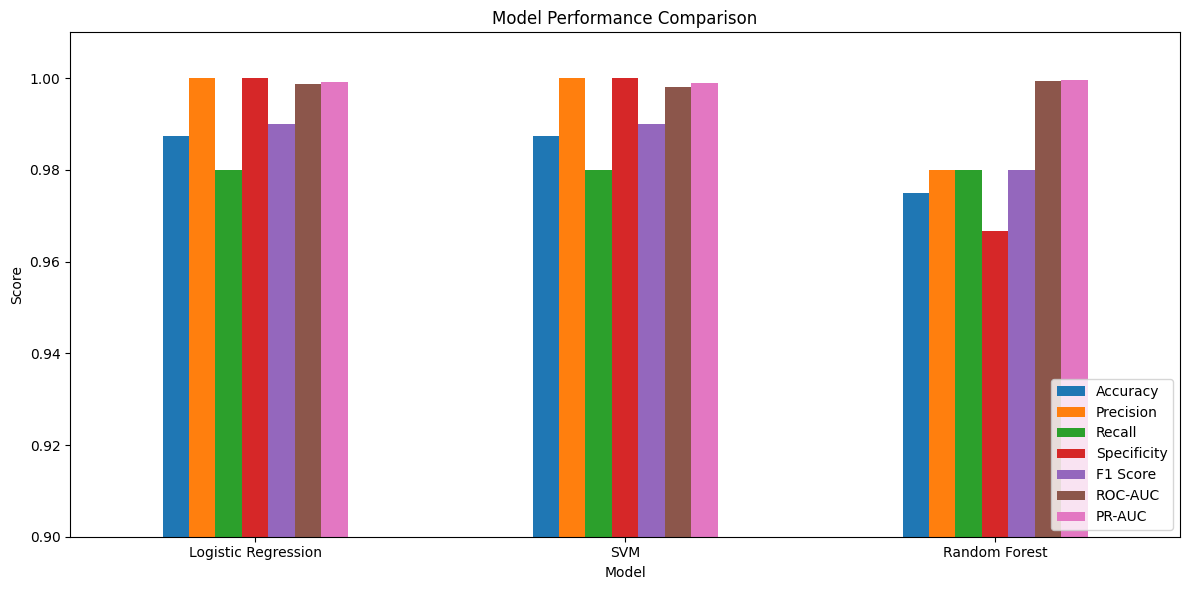

In [224]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.90, 1.01)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

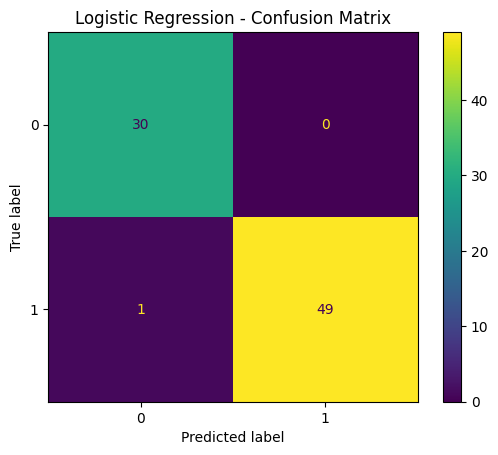

In [225]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr_tuned
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

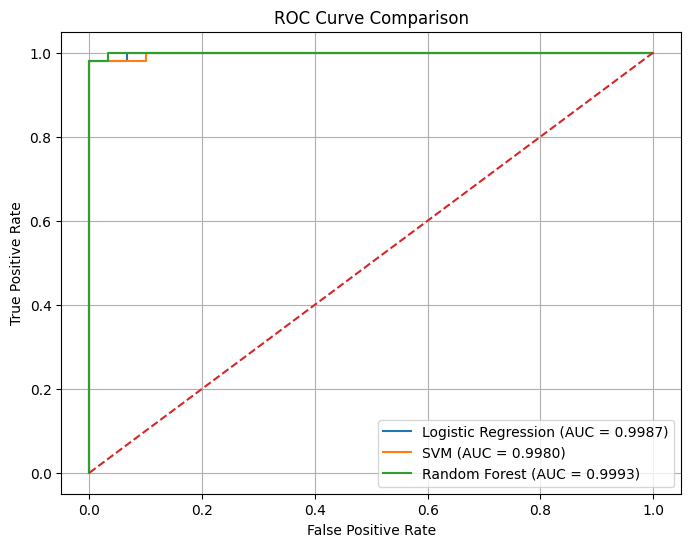

In [226]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr_tuned
)

fpr_svm, tpr_svm, _ = roc_curve(
    y_test,
    y_prob_svm_tuned
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf_tuned
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr_tuned):.4f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {roc_auc_score(y_test, y_prob_svm_tuned):.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf_tuned):.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [227]:
feature_names = preprocessor.get_feature_names_out()

coefficients = best_logistic.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Coefficient
21,cat__appet_poor,4.531489,4.531489
18,cat__htn_yes,4.395471,4.395471
2,num__sg,-3.655605,3.655605
19,cat__dm_yes,3.208115,3.208115
7,num__sc,2.069018,2.069018
10,num__hemo,-1.809085,1.809085
11,num__pcv,-1.644521,1.644521
13,num__rc,-1.563316,1.563316
4,num__su,1.560444,1.560444
3,num__al,1.426532,1.426532


In [228]:
print("Top 10 most influential features:")
print(feature_importance.head(10))

Top 10 most influential features:
            Feature  Coefficient  Absolute_Coefficient
21  cat__appet_poor     4.531489              4.531489
18     cat__htn_yes     4.395471              4.395471
2           num__sg    -3.655605              3.655605
19      cat__dm_yes     3.208115              3.208115
7           num__sc     2.069018              2.069018
10        num__hemo    -1.809085              1.809085
11         num__pcv    -1.644521              1.644521
13          num__rc    -1.563316              1.563316
4           num__su     1.560444              1.560444
3           num__al     1.426532              1.426532


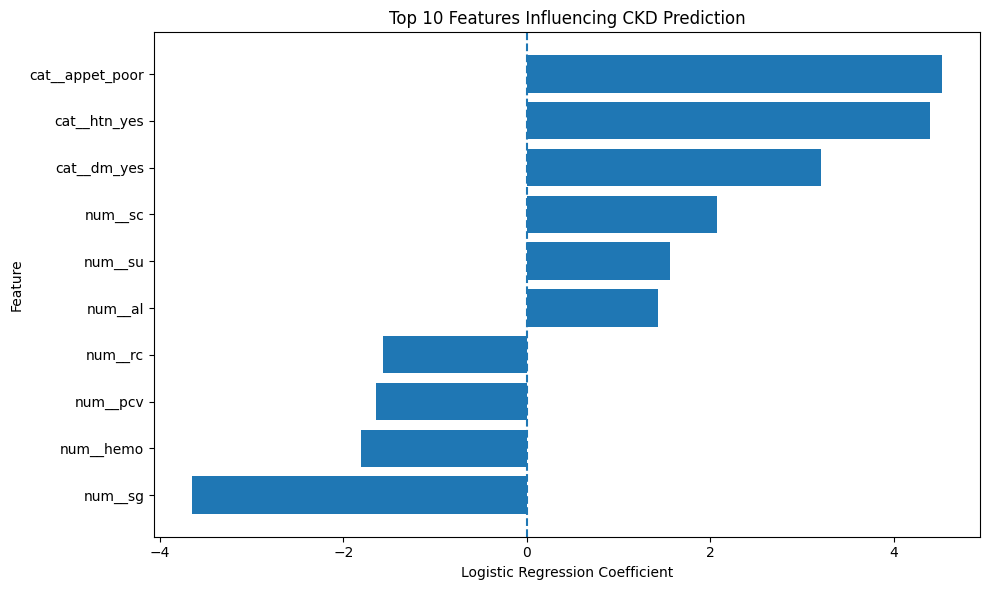

In [229]:
top_features = feature_importance.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing CKD Prediction")
plt.tight_layout()
plt.show()

In [230]:
from sklearn.pipeline import Pipeline

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=10,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

In [231]:
final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(weights='distance')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bp', 'sg', 'al',
                                                   'su', 'bgr', 'bu', 'sc',
                                                   'sod', 'pot', 'hemo', 'pcv',
                                                   'wc', 'rc']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['rbc', 'pc', 'pcc', 'ba',
                                                   'htn', 'dm', 'cad', 'appet',
                                                   'pe', 'ane'])])),
                ('classifier',
                 LogisticRegression(C=10, max_iter=2000, random_state=42,
                                    solver='liblinear'))])

In [232]:
y_pred_final = final_model.predict(X_test)

y_prob_final = final_model.predict_proba(X_test)[:, 1]

In [233]:
print("Final Model Performance")

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

Final Model Performance
Accuracy : 0.9875
Precision: 1.0
Recall   : 0.98
F1 Score : 0.98989898989899
ROC-AUC  : 0.9986666666666667

Confusion Matrix:
[[30  0]
 [ 1 49]]


In [234]:
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        C=10,
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

In [235]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        C=100,
        gamma=0.01,
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

In [236]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42
    ))
])

In [238]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
final_models = {
    "Logistic Regression": lr_pipeline,
    "SVM": svm_pipeline,
    "Random Forest": rf_pipeline
}

for name, model in final_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    print(f"\n{name}")
    print("-" * 40)

    for metric in scoring:
        values = scores[f"test_{metric}"]
        print(
            f"{metric.upper():10}: "
            f"{values.mean():.4f} ± {values.std():.4f}"
        )


Logistic Regression
----------------------------------------
ACCURACY  : 0.9750 ± 0.0212
PRECISION : 0.9951 ± 0.0098
RECALL    : 0.9650 ± 0.0374
F1        : 0.9793 ± 0.0179
ROC_AUC   : 0.9971 ± 0.0036

SVM
----------------------------------------
ACCURACY  : 0.9719 ± 0.0153
PRECISION : 0.9900 ± 0.0123
RECALL    : 0.9650 ± 0.0255
F1        : 0.9771 ± 0.0127
ROC_AUC   : 0.9971 ± 0.0030

Random Forest
----------------------------------------
ACCURACY  : 0.9812 ± 0.0153
PRECISION : 0.9810 ± 0.0233
RECALL    : 0.9900 ± 0.0200
F1        : 0.9851 ± 0.0122
ROC_AUC   : 0.9984 ± 0.0016


In [239]:
final_rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42
    ))
])
final_rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(weights='distance')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bp', 'sg', 'al',
                                                   'su', 'bgr', 'bu', 'sc',
                                                   'sod', 'pot', 'hemo', 'pcv',
                                                   'wc', 'rc']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['rbc', 'pc', 'pcc', 'ba',
                                                   'htn', 'dm', 'cad', 'appet',
                                                   'pe', 'ane'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [240]:
y_pred_final = final_rf_pipeline.predict(X_test)

y_prob_final = final_rf_pipeline.predict_proba(X_test)[:, 1]

print("FINAL RANDOM FOREST")

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

FINAL RANDOM FOREST
Accuracy : 0.975
Precision: 0.98
Recall   : 0.98
F1 Score : 0.98
ROC-AUC  : 0.9993333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        30
           1       0.98      0.98      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.97      0.97        80
weighted avg       0.97      0.97      0.97        80


Confusion Matrix:
[[29  1]
 [ 1 49]]


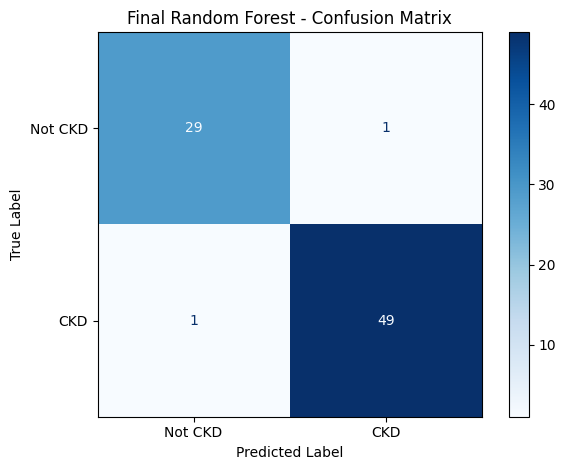

In [241]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=["Not CKD", "CKD"],
    cmap="Blues"
)

plt.title("Final Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

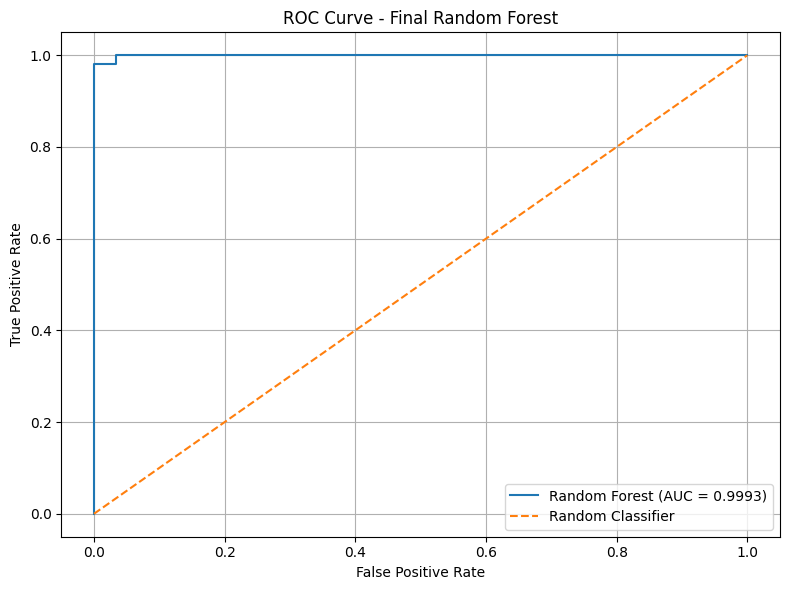

In [242]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)

# Calculate ROC-AUC
auc_score = roc_auc_score(y_test, y_prob_final)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.4f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Random Forest")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()

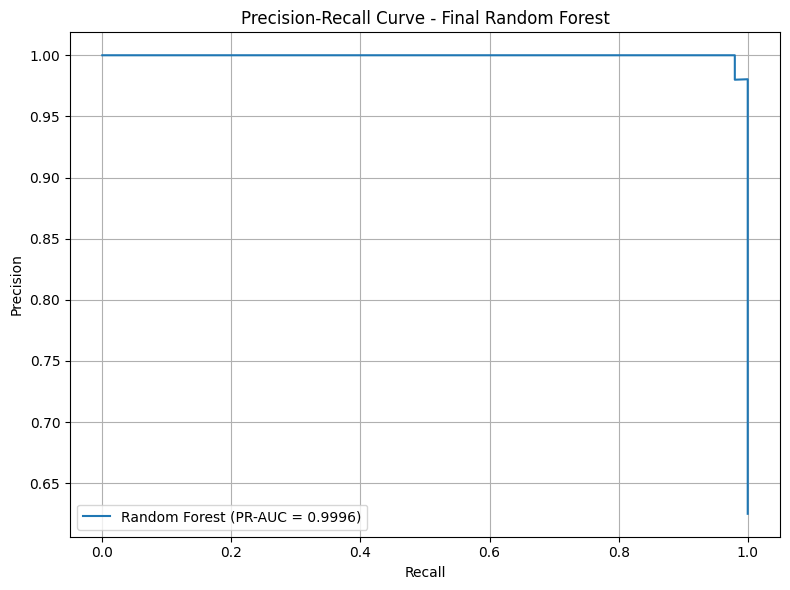

In [244]:
# =========================================================
# PRECISION-RECALL CURVE
# =========================================================
# Extract predicted probabilities for the positive class from your tuned model
y_prob_rf = best_rf.predict_proba(X_test_preprocessed)[:, 1]

# Calculate Precision-Recall curve and PR-AUC score
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc = average_precision_score(y_test, y_prob_rf)

# Plotting the curve
plt.figure(figsize=(8, 6))
plt.plot(
    recall,
    precision,
    label=f"Random Forest (PR-AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final Random Forest")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [245]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = final_rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get Random Forest feature importance
importances = final_rf_pipeline.named_steps[
    "classifier"
].feature_importances_

# Create DataFrame
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

# Display top 10
print("Top 10 Random Forest Features:")
print(rf_importance.head(10))

Top 10 Random Forest Features:
         Feature  Importance
2        num__sg    0.225159
10     num__hemo    0.175592
7        num__sc    0.125392
11      num__pcv    0.110922
3        num__al    0.071258
18  cat__htn_yes    0.053354
13       num__rc    0.046670
19   cat__dm_yes    0.039493
5       num__bgr    0.029398
6        num__bu    0.023177


In [246]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

final_rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42
    ))
])

In [247]:
final_rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(weights='distance')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bp', 'sg', 'al',
                                                   'su', 'bgr', 'bu', 'sc',
                                                   'sod', 'pot', 'hemo', 'pcv',
                                                   'wc', 'rc']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['rbc', 'pc', 'pcc', 'ba',
                                                   'htn', 'dm', 'cad', 'appet',
                                                   'pe', 'ane'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [248]:
y_pred_final = final_rf_pipeline.predict(X_test)
y_prob_final = final_rf_pipeline.predict_proba(X_test)[:, 1]

# =========================================================
# FINAL MODEL EVALUATION
# =========================================================

final_metrics = evaluate_model(
    final_rf_pipeline,
    X_test,
    y_test
)

print("FINAL RANDOM FOREST")
print("=" * 50)

print(f"Accuracy    : {final_metrics['accuracy']:.4f}")
print(f"Precision   : {final_metrics['precision']:.4f}")
print(f"Sensitivity : {final_metrics['recall']:.4f}")
print(f"Specificity : {final_metrics['specificity']:.4f}")
print(f"F1 Score    : {final_metrics['f1_score']:.4f}")
print(f"ROC-AUC     : {final_metrics['roc_auc']:.4f}")
print(f"PR-AUC      : {final_metrics['pr_auc']:.4f}")

print("\nConfusion Matrix")
print("=" * 50)

print(
    confusion_matrix(
        y_test,
        final_metrics["y_pred"]
    )
)

print("\nTN:", final_metrics["tn"])
print("FP:", final_metrics["fp"])
print("FN:", final_metrics["fn"])
print("TP:", final_metrics["tp"])

print("Final Deployment Pipeline")

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_final))

FINAL RANDOM FOREST
Accuracy    : 0.9750
Precision   : 0.9800
Sensitivity : 0.9800
Specificity : 0.9667
F1 Score    : 0.9800
ROC-AUC     : 0.9993
PR-AUC      : 0.9996

Confusion Matrix
[[29  1]
 [ 1 49]]

TN: 29
FP: 1
FN: 1
TP: 49
Final Deployment Pipeline
Accuracy : 0.975
Precision: 0.98
Recall   : 0.98
F1 Score : 0.98
ROC-AUC  : 0.9993333333333333


In [249]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))


Confusion Matrix:
[[29  1]
 [ 1 49]]


In [250]:
joblib.dump(
    final_rf_pipeline,
    "ckd_random_forest_pipeline.joblib"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [251]:
loaded_pipeline = joblib.load(
    "ckd_random_forest_pipeline.joblib"
)

loaded_predictions = loaded_pipeline.predict(X_test)

print(
    "Predictions identical:",
    np.array_equal(y_pred_final, loaded_predictions)
)

Predictions identical: True


In [252]:
metadata = {
    "model": "Random Forest",
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "features": list(X_train.columns),
    "target": y_train.name
}

joblib.dump(
    metadata,
    "ckd_model_metadata.joblib"
)

print("Metadata saved successfully!")

Metadata saved successfully!


In [253]:
# =========================================================
# SAVE EVALUATION METADATA
# =========================================================

evaluation_metadata = {
    "model": "Random Forest",
    "metrics": {
        "accuracy": float(final_metrics["accuracy"]),
        "precision": float(final_metrics["precision"]),
        "recall": float(final_metrics["recall"]),
        "sensitivity": float(final_metrics["recall"]),
        "specificity": float(final_metrics["specificity"]),
        "f1_score": float(final_metrics["f1_score"]),
        "roc_auc": float(final_metrics["roc_auc"]),
        "pr_auc": float(final_metrics["pr_auc"])
    },
    "confusion_matrix": {
        "tn": int(final_metrics["tn"]),
        "fp": int(final_metrics["fp"]),
        "fn": int(final_metrics["fn"]),
        "tp": int(final_metrics["tp"])
    }
}

joblib.dump(
    evaluation_metadata,
    "ckd_evaluation_metadata.joblib"
)

print("Evaluation metadata saved successfully!")

Evaluation metadata saved successfully!


In [254]:
print("Input features:")
for i, col in enumerate(X_train.columns):
    print(i, col)

print("\nNumber of features:", X_train.shape[1])

Input features:
0 age
1 bp
2 sg
3 al
4 su
5 rbc
6 pc
7 pcc
8 ba
9 bgr
10 bu
11 sc
12 sod
13 pot
14 hemo
15 pcv
16 wc
17 rc
18 htn
19 dm
20 cad
21 appet
22 pe
23 ane

Number of features: 24


In [255]:
import sys
import sklearn
import numpy
import joblib
import pandas

print("Python       :", sys.version)
print("scikit-learn :", sklearn.__version__)
print("numpy        :", numpy.__version__)
print("joblib       :", joblib.__version__)
print("pandas       :", pandas.__version__)

Python       : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
scikit-learn : 1.6.1
numpy        : 2.1.3
joblib       : 1.6.0
pandas       : 2.2.3
